In [101]:
import numpy as np
import matplotlib.pyplot as plt


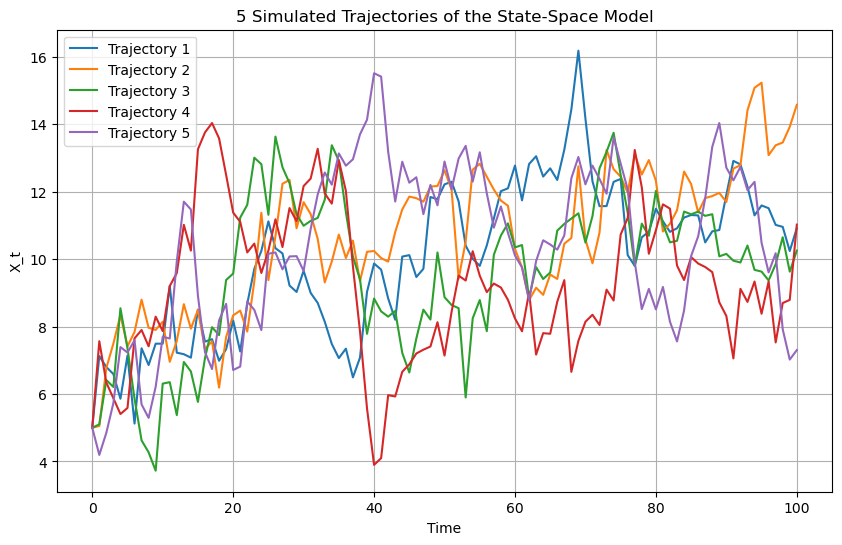

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
a = 0.9
b = 1
sigma = 1
n = 100
num_paths = 5
X0 = 5

# Set seed for reproducibility
np.random.seed(1)

# Store trajectories
trajectories = np.zeros((num_paths, n+1))

# Simulate
for i in range(num_paths):
    X = np.zeros(n+1)
    X[0] = X0
    for t in range(1, n+1):
        e_t = np.random.normal(0, sigma)
        X[t] = a * X[t-1] + b + e_t
    trajectories[i, :] = X

# Plot
plt.figure(figsize=(10, 6))
for i in range(num_paths):
    plt.plot(trajectories[i], label=f'Trajectory {i+1}')

plt.title('5 Simulated Trajectories of the State-Space Model')
plt.xlabel('Time')
plt.ylabel('X_t')
plt.legend()
plt.grid(True)
plt.savefig("Simulated Realizations")
plt.show()

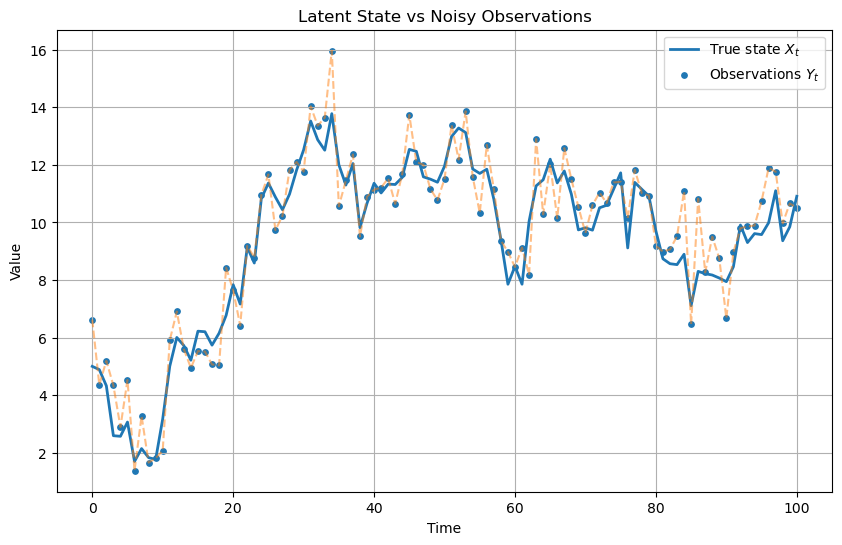

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
a = 0.9
b = 1
sigma1 = 1   # system noise std
sigma2 = 1   # observation noise std
n = 100
X0 = 5

# Reproducibility
np.random.seed(1)

# Initialize arrays
X = np.zeros(n+1)
Y = np.zeros(n+1)

X[0] = X0
Y[0] = X[0] + np.random.normal(0, sigma2)

# Simulation
for t in range(1, n+1):
    e1 = np.random.normal(0, sigma1)
    e2 = np.random.normal(0, sigma2)
    
    X[t] = a * X[t-1] + b + e1
    Y[t] = X[t] + e2

# Plot
plt.figure(figsize=(10, 6))

# True state (smooth line)
plt.plot(X, label='True state $X_t$', linewidth=2)

# Observations (noisy)
plt.scatter(range(n+1), Y, label='Observations $Y_t$', s=15)
plt.plot(Y, linestyle='--', alpha=0.5)

plt.title('Latent State vs Noisy Observations')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.savefig("Single realization of the process")

plt.show()

Since the observation model $Y_t = X_t + \epsilon_2$, the noisy observations follow the true state $X_t$ closely, but fluctuate around it due to observation noise

## 1.3

The Kalman filter tracks the latent state well. The predicted state follows the general movement of the true state, while the observations are more scattered due to observation noise. The 95% confidence interval captures most of the true state values. The residuals fluctuate around zero, suggesting that the one-step-ahead predictions are approximately unbiased. Large residuals occur when the state noise produces sudden changes that cannot be predicted from previous observations

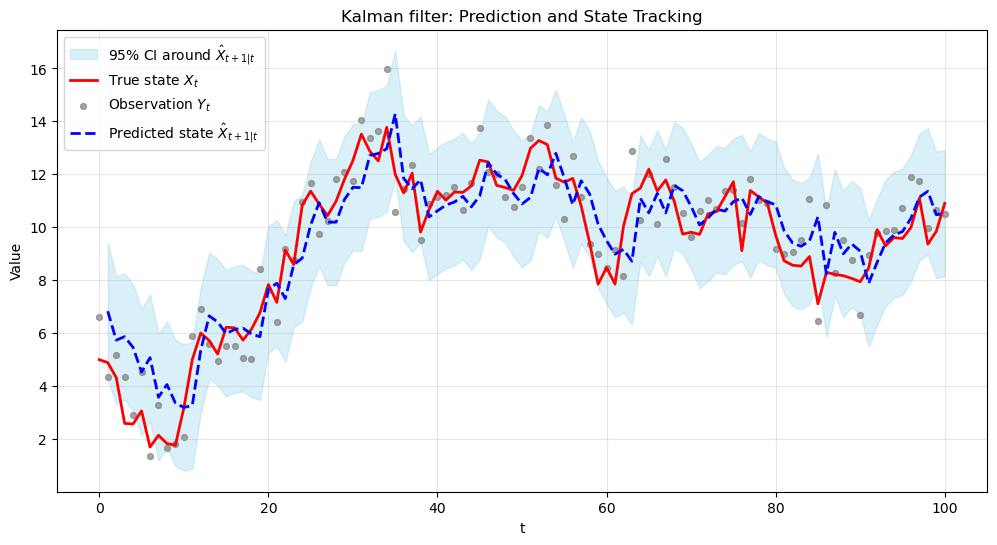

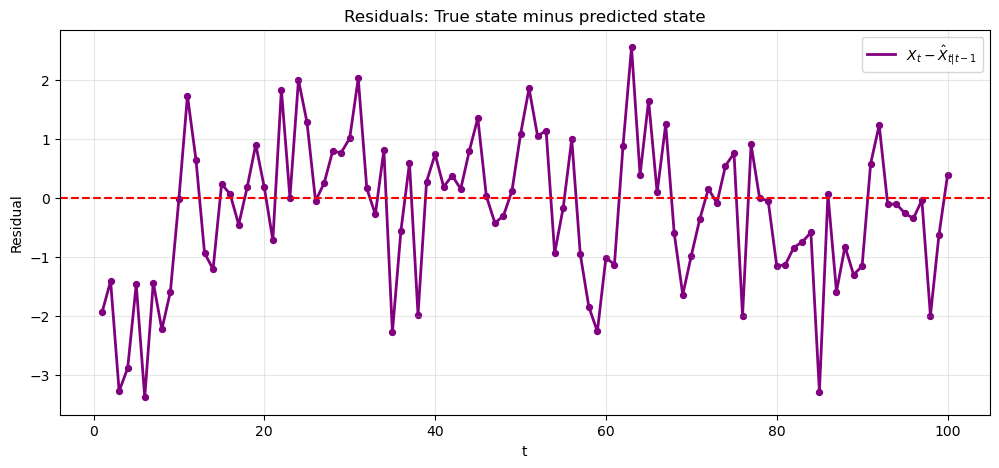

First x_pred_next values:
[6.82900984 5.73610738 5.86751204 5.45702806 4.53139769 5.07610174]

First P_pred_next values:
[1.73636364 1.51398671 1.48780259 1.48441147 1.48396705 1.48390872]

First innovations:
[ 1.62434536 -2.46893801 -0.54424915 -1.53043343 -2.5661557  -0.0040102 ]

First innovation variances:
[11.          2.73636364  2.51398671  2.48780259  2.48441147  2.48396705]

Residual mean:
-0.21989764905140496

Residual standard deviation:
1.2307522469686636


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1.2 DATA SIMULATION ---
np.random.seed(1)

a = 0.9
b = 1
sigma1 = 1
sigma2 = 1
X0 = 5
n = 100

time = np.arange(0, n + 1)

X_t = np.zeros(n + 1)
Y_t = np.zeros(n + 1)

X_t[0] = X0
Y_t[0] = X_t[0] + np.random.normal(0, sigma2)

for t in range(1, n + 1):
    X_t[t] = a * X_t[t - 1] + b + np.random.normal(0, sigma1)
    Y_t[t] = X_t[t] + np.random.normal(0, sigma2)


# --- 1.3 KALMAN FILTER ---
def myKalmanFilter(y, theta, R, x_prior=5, P_prior=10):
    """
    Kalman filter for:

        X_t = a X_{t-1} + b + e_t
        Y_t = X_t + v_t

    Returns both:
        x_pred       = prediction of X_t before observing Y_t
        x_pred_next  = prediction of X_{t+1} after observing Y_t
    """

    y = np.asarray(y, dtype=float)

    a = theta[0]
    b = theta[1]
    sigma1 = theta[2]

    Q = sigma1**2
    N = len(y)

    x_pred = np.zeros(N)
    P_pred = np.zeros(N)

    x_filt = np.zeros(N)
    P_filt = np.zeros(N)

    innovation = np.zeros(N)
    innovation_var = np.zeros(N)

    x_pred_next = np.zeros(N)
    P_pred_next = np.zeros(N)

    for t in range(N):

        # Prediction of X_t before observing Y_t
        if t == 0:
            x_pred[t] = x_prior
            P_pred[t] = P_prior
        else:
            x_pred[t] = a * x_filt[t - 1] + b
            P_pred[t] = a**2 * P_filt[t - 1] + Q

        # Update with observation Y_t
        innovation[t] = y[t] - x_pred[t]
        innovation_var[t] = P_pred[t] + R

        K_t = P_pred[t] / innovation_var[t]

        x_filt[t] = x_pred[t] + K_t * innovation[t]
        P_filt[t] = (1 - K_t) * P_pred[t]

        # Prediction of X_{t+1|t}
        x_pred_next[t] = a * x_filt[t] + b
        P_pred_next[t] = a**2 * P_filt[t] + Q

    return {
        "x_pred": x_pred,
        "P_pred": P_pred,
        "x_filt": x_filt,
        "P_filt": P_filt,
        "innovation": innovation,
        "innovation_var": innovation_var,
        "x_pred_next": x_pred_next,
        "P_pred_next": P_pred_next
    }


# Run Kalman filter
theta = [a, b, sigma1]
R = sigma2**2

kf = myKalmanFilter(
    y=Y_t,
    theta=theta,
    R=R,
    x_prior=X0,
    P_prior=10
)


# --- 95% CI around X_{t+1|t} ---
ci_lower = kf["x_pred_next"] - 1.96 * np.sqrt(kf["P_pred_next"])
ci_upper = kf["x_pred_next"] + 1.96 * np.sqrt(kf["P_pred_next"])


# Align X_{t+1|t} with the time it predicts
# x_pred_next[0] predicts X_1, so plot it at time 1
pred_time = np.arange(1, n + 1)

pred_mean = kf["x_pred_next"][:n]
pred_lower = ci_lower[:n]
pred_upper = ci_upper[:n]


# --- PLOTTING ---
plt.figure(figsize=(12, 6))

plt.fill_between(
    pred_time,
    pred_lower,
    pred_upper,
    color="skyblue",
    alpha=0.3,
    label=r"95% CI around $\hat{X}_{t+1|t}$"
)

plt.plot(
    time,
    X_t,
    color="red",
    linewidth=2,
    label=r"True state $X_t$"
)

plt.scatter(
    time,
    Y_t,
    color="gray",
    s=18,
    alpha=0.7,
    label=r"Observation $Y_t$"
)

plt.plot(
    pred_time,
    pred_mean,
    color="blue",
    linestyle="--",
    linewidth=2,
    label=r"Predicted state $\hat{X}_{t+1|t}$"
)

plt.title("Kalman filter: Prediction and State Tracking")
plt.xlabel("t")
plt.ylabel("Value")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# --- RESIDUALS: True state minus predicted state ---
# x_pred_next[0:n] predicts X_1, ..., X_n
true_next = X_t[1:n + 1]
pred_next = kf["x_pred_next"][:n]

residuals_pred = true_next - pred_next

plt.figure(figsize=(12, 5))

plt.plot(
    pred_time,
    residuals_pred,
    color="purple",
    linewidth=2,
    label=r"$X_t - \hat{X}_{t|t-1}$"
)

plt.scatter(
    pred_time,
    residuals_pred,
    color="purple",
    s=18
)

plt.axhline(0, color="red", linestyle="--")

plt.title("Residuals: True state minus predicted state")
plt.xlabel("t")
plt.ylabel("Residual")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


print("First x_pred_next values:")
print(kf["x_pred_next"][:6])

print("\nFirst P_pred_next values:")
print(kf["P_pred_next"][:6])

print("\nFirst innovations:")
print(kf["innovation"][:6])

print("\nFirst innovation variances:")
print(kf["innovation_var"][:6])

print("\nResidual mean:")
print(np.mean(residuals_pred))

print("\nResidual standard deviation:")
print(np.std(residuals_pred, ddof=1))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize


# ------------------------------------------------------------
# 1.3 Kalman filter
# ------------------------------------------------------------

def myKalmanFilter(y, theta, R, x_prior=0, P_prior=10):
    y = np.asarray(y, dtype=float)

    a = theta[0]
    b = theta[1]
    sigma1 = theta[2]

    Q = sigma1**2
    N = len(y)

    x_pred = np.zeros(N)
    P_pred = np.zeros(N)
    x_filt = np.zeros(N)
    P_filt = np.zeros(N)
    innovation = np.zeros(N)
    innovation_var = np.zeros(N)

    x_pred_next = np.zeros(N)
    P_pred_next = np.zeros(N)

    for t in range(N):

        # Prediction of X_t before observing Y_t
        if t == 0:
            x_pred[t] = x_prior
            P_pred[t] = P_prior
        else:
            x_pred[t] = a * x_filt[t - 1] + b
            P_pred[t] = a**2 * P_filt[t - 1] + Q

        # Update with observation Y_t
        innovation[t] = y[t] - x_pred[t]
        innovation_var[t] = P_pred[t] + R

        K_t = P_pred[t] / innovation_var[t]

        x_filt[t] = x_pred[t] + K_t * innovation[t]
        P_filt[t] = (1 - K_t) * P_pred[t]

        # Prediction of X_{t+1|t}
        x_pred_next[t] = a * x_filt[t] + b
        P_pred_next[t] = a**2 * P_filt[t] + Q

    return {
        "x_pred": x_pred,
        "P_pred": P_pred,
        "x_filt": x_filt,
        "P_filt": P_filt,
        "innovation": innovation,
        "innovation_var": innovation_var,
        "x_pred_next": x_pred_next,
        "P_pred_next": P_pred_next
    }


# ------------------------------------------------------------
# 1.4 Negative log-likelihood function
# ------------------------------------------------------------

def myLogLikFun(theta, y, R, x_prior=0, P_prior=10):
    a = theta[0]
    b = theta[1]
    sigma1 = theta[2]

    # sigma1 must be positive
    if sigma1 <= 0:
        return np.inf

    kf_result = myKalmanFilter(
        y=y,
        theta=[a, b, sigma1],
        R=R,
        x_prior=x_prior,
        P_prior=P_prior
    )

    err = kf_result["innovation"]
    S = kf_result["innovation_var"]

    # Variances must be positive
    if np.any(S <= 0):
        return np.inf

    # Log-likelihood from Gaussian innovations
    logL = np.sum(-0.5 * (np.log(2 * np.pi * S) + (err**2 / S)))

    # Return negative log-likelihood for minimization
    return -logL


# ------------------------------------------------------------
# Data simulation function
# ------------------------------------------------------------

def simulate_system(a, b, sigma1, sigma2, X0, n):
    X_t = np.zeros(n + 1)
    Y_t = np.zeros(n + 1)

    X_t[0] = X0
    Y_t[0] = X_t[0] + np.random.normal(0, sigma2)

    for t in range(1, n + 1):
        X_t[t] = a * X_t[t - 1] + b + np.random.normal(0, sigma1)
        Y_t[t] = X_t[t] + np.random.normal(0, sigma2)

    return X_t, Y_t


# ------------------------------------------------------------
# One estimation study
# ------------------------------------------------------------

def run_estimation_study(
    a_true,
    b_true,
    sigma1_true,
    sigma2=1,
    X0=5,
    n=100,
    n_sims=100
):
    estimates = []

    R = sigma2**2

    for _ in range(n_sims):

        X_t, Y_t = simulate_system(
            a=a_true,
            b=b_true,
            sigma1=sigma1_true,
            sigma2=sigma2,
            X0=X0,
            n=n
        )

        fit = minimize(
            fun=myLogLikFun,
            x0=np.array([0.5, 0.5, 1.0]),
            args=(Y_t, R, X0, 10),
            method="L-BFGS-B",
            bounds=[(None, None), (None, None), (0.001, None)]
        )

        if fit.success:
            estimates.append(fit.x)

    return np.array(estimates)


# ------------------------------------------------------------
# Run the three required cases
# ------------------------------------------------------------

np.random.seed(1)

cases = [
    {
        "params": [0.9, 1, 1],
        "label": "Base case: a = 0.9, b = 1, sigma1 = 1"
    },
    {
        "params": [0.9, 5, 1],
        "label": "High bias: a = 0.9, b = 5, sigma1 = 1"
    },
    {
        "params": [0.9, 1, 5],
        "label": "High process noise: a = 0.9, b = 1, sigma1 = 5"
    }
]

results = []

for case in cases:
    p = case["params"]

    estimates = run_estimation_study(
        a_true=p[0],
        b_true=p[1],
        sigma1_true=p[2],
        sigma2=1,
        X0=5,
        n=100,
        n_sims=100
    )

    results.append(estimates)


# ------------------------------------------------------------
# Boxplots in 2x2 layout
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, case in enumerate(cases):
    p = np.array(case["params"])
    estimates = results[i]

    ax = axes[i]

    ax.boxplot(
        estimates,
        tick_labels=["a", "b", r"$\sigma_1$"],
        boxprops=dict(color="0.65"),
        whiskerprops=dict(color="0.65"),
        capprops=dict(color="0.65"),
        medianprops=dict(color="tab:orange"),
        flierprops=dict(
            marker="o",
            markersize=3,
            markerfacecolor="0.75",
            markeredgecolor="0.75",
            alpha=0.6
        )
    )

    ax.scatter(
        [1, 2, 3],
        p,
        color="red",
        s=14,
        label="True Value",
        zorder=3
    )

    ax.set_title(case["label"], fontsize=9)
    ax.grid(axis="y", linestyle="-", alpha=0.2)
    ax.legend(loc="upper left", fontsize=8, frameon=False)

for ax in axes[len(cases):]:
    ax.set_axis_off()

plt.tight_layout()
plt.savefig("MLE.png", dpi=300, bbox_inches="tight")
plt.show()


# ------------------------------------------------------------
# Numerical summaries
# ------------------------------------------------------------

param_names = ["a", "b", "sigma1"]

for i, case in enumerate(cases):
    estimates = results[i]
    p = np.array(case["params"])

    print("\n" + case["label"])

    print("True values:")
    for name, value in zip(param_names, p):
        print(f"{name}: {value:.4f}")

    print("\nMean estimates:")
    mean_estimates = np.mean(estimates, axis=0)
    for name, value in zip(param_names, mean_estimates):
        print(f"{name}: {value:.4f}")

    print("\nStandard deviations:")
    std_estimates = np.std(estimates, axis=0, ddof=1)
    for name, value in zip(param_names, std_estimates):
        print(f"{name}: {value:.4f}")

In [ ]:
# 1.5

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm, t

np.random.seed(1)

# Use the same parameter order as in exercise 1.4: [a, b, sigma1]
a_true = 0.9
b_true = 1.0
sigma1_true = 1.0
sigma2 = 1.0
X0 = 5
n = 100
n_sims = 100
nu_values = [100, 5, 2, 1]

p_true = np.array([a_true, b_true, sigma1_true])
param_names = ["a", "b", "sigma1"]
param_labels = ["a", "b", r"$\sigma_1$"]

# Compare the Gaussian assumption with heavier-tailed Student-t innovations.
x_axis = np.linspace(-6, 6, 600)

plt.figure(figsize=(10, 5))
plt.plot(x_axis, norm.pdf(x_axis), "k--", lw=2, label="Normal")

for nu in nu_values:
    plt.plot(x_axis, t.pdf(x_axis, df=nu), label=f"Student-t (nu={nu})")

plt.title("Normal and Student-t Process-Noise Densities")
plt.xlabel("Noise value")
plt.ylabel("Density")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


def simulate_t_system(a, b, sigma1, sigma2, X0, n, nu):
    X_t = np.zeros(n + 1)
    Y_t = np.zeros(n + 1)

    X_t[0] = X0
    Y_t[0] = X_t[0] + np.random.normal(0, sigma2)

    for t_idx in range(1, n + 1):
        process_noise = sigma1 * np.random.standard_t(df=nu)
        observation_noise = np.random.normal(0, sigma2)

        X_t[t_idx] = a * X_t[t_idx - 1] + b + process_noise
        Y_t[t_idx] = X_t[t_idx] + observation_noise

    return X_t, Y_t


def run_t_study(nu, n_sims=n_sims):
    estimates = []
    R = sigma2**2

    for _ in range(n_sims):
        _, Y_t = simulate_t_system(
            a=a_true,
            b=b_true,
            sigma1=sigma1_true,
            sigma2=sigma2,
            X0=X0,
            n=n,
            nu=nu
        )

        fit = minimize(
            fun=myLogLikFun,
            x0=np.array([0.5, 0.5, 1.0]),
            args=(Y_t, R, X0, 10),
            method="L-BFGS-B",
            bounds=[(None, None), (None, None), (0.001, None)],
            options={"maxiter": 500}
        )

        if fit.success and np.all(np.isfinite(fit.x)):
            estimates.append(fit.x)

    return np.array(estimates)


# Run the Student-t estimation study.
t_study_results = {}

for nu in nu_values:
    print(f"Running Student-t simulation for nu = {nu}...")
    t_study_results[nu] = run_t_study(nu)


# Plot the parameter estimates.
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, nu in enumerate(nu_values):
    ax = axes[i]
    estimates = t_study_results[nu]

    if len(estimates) == 0:
        ax.text(0.5, 0.5, "No successful fits", ha="center", va="center")
        ax.set_axis_off()
        continue

    ax.boxplot(
        estimates,
        tick_labels=param_labels,
        patch_artist=True,
        boxprops=dict(facecolor="white")
    )
    ax.scatter([1, 2, 3], p_true, color="red", label="True value", zorder=3)

    ax.set_title(f"Student-t Process Noise (nu = {nu})")
    ax.set_ylabel("Estimated value")
    ax.grid(axis="y", linestyle="dotted", alpha=0.6)
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()


# Numerical summaries.
for nu in nu_values:
    estimates = t_study_results[nu]

    print(f"\nnu = {nu}")
    print(f"Successful fits: {len(estimates)} / {n_sims}")

    if len(estimates) == 0:
        continue

    print("Mean estimates:")
    for name, value in zip(param_names, np.mean(estimates, axis=0)):
        print(f"{name}: {value:.4f}")

    print("Standard deviations:")
    for name, value in zip(param_names, np.std(estimates, axis=0, ddof=1)):
        print(f"{name}: {value:.4f}")
